**Corporate Financial Analysis**

**Objective**

This notebook analyzes corporate financial performance using the integrated financial dataset created from SEC XBRL filings.

The analysis focuses on: Profitability, Liquidity, Leverage, Cash generation and Performance trends across companies.

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine
from dotenv import load_dotenv

import os

import matplotlib.pyplot as plt

**Connect to PosgreSQL**

In [ ]:
import pandas as pd
from mydatabase_db_core.connection import get_db_engine

engine = get_db_engine()

query = """
SELECT *
FROM corp_fin.financials_analysis_view;
"""

df = pd.read_sql(query, engine)

print("Connected successfully to database!")

df.head()

Connected successfully to database!


,company_id,period_start,period_end,fiscal_year,fiscal_period,filing_form,filed_date,revenue,operating_income,net_income,...,investing_cash_flow,financing_cash_flow,capital_expenditure,dividends_paid,ticker,company_name,sector,country,industry,exchange
0,1,2007-07-01,2008-06-30,2010,FY,10-K,None,NaN,2.227100e+10,1.768100e+10,...,-4.587000e+09,-1.293400e+10,3.182000e+09,NaN,MSFT,Microsoft Corporation,Technology,USA,Software,NASDAQ
1,1,2008-07-01,2009-06-30,2011,FY,10-K,None,NaN,2.036300e+10,1.456900e+10,...,-1.577000e+10,-7.463000e+09,3.119000e+09,NaN,MSFT,Microsoft Corporation,Technology,USA,Software,NASDAQ
2,1,2009-07-01,2010-06-30,2012,FY,10-K,None,NaN,2.409800e+10,1.876000e+10,...,-1.131400e+10,-1.329100e+10,1.977000e+09,NaN,MSFT,Microsoft Corporation,Technology,USA,Software,NASDAQ
3,1,2011-07-01,2012-06-30,2014,FY,10-K,None,NaN,2.176300e+10,1.697800e+10,...,NaN,NaN,2.305000e+09,NaN,MSFT,Microsoft Corporation,Technology,USA,Software,NASDAQ
4,1,2013-07-01,2014-06-30,2016,FY,10-K,None,NaN,2.775900e+10,2.207400e+10,...,NaN,NaN,5.485000e+09,NaN,MSFT,Microsoft Corporation,Technology,USA,Software,NASDAQ


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company_id           880 non-null    int64  
 1   period_start         880 non-null    object 
 2   period_end           880 non-null    object 
 3   fiscal_year          880 non-null    int64  
 4   fiscal_period        880 non-null    str    
 5   filing_form          880 non-null    str    
 6   filed_date           0 non-null      object 
 7   revenue              250 non-null    float64
 8   operating_income     549 non-null    float64
 9   net_income           749 non-null    float64
 10  rd_expense           433 non-null    float64
 11  income_tax           851 non-null    float64
 12  assets               303 non-null    float64
 13  liabilities          149 non-null    float64
 14  equity               425 non-null    float64
 15  cash                 531 non-null    float64
 16  i

In [4]:
df.shape

(880, 31)

In [5]:
df.describe()

,company_id,fiscal_year,revenue,operating_income,net_income,rd_expense,income_tax,assets,liabilities,equity,cash,inventory,current_assets,current_liabilities,long_term_debt,operating_cash_flow,investing_cash_flow,financing_cash_flow,capital_expenditure,dividends_paid
count,880.000000,880.000000,2.500000e+02,5.490000e+02,7.490000e+02,4.330000e+02,8.510000e+02,3.030000e+02,1.490000e+02,4.250000e+02,5.310000e+02,1.420000e+02,1.620000e+02,1.620000e+02,1.280000e+02,7.780000e+02,7.800000e+02,7.810000e+02,6.170000e+02,3.770000e+02
mean,31.717045,2018.218182,1.142491e+11,1.231165e+10,8.944292e+09,5.742449e+09,3.063344e+09,4.652118e+11,4.200201e+11,5.951976e+10,1.410729e+10,6.209573e+09,3.648123e+10,2.742923e+10,2.553420e+10,1.484292e+10,-1.178259e+10,-2.047243e+09,4.658739e+09,3.360480e+09
std,15.766735,5.189921,1.463374e+11,1.989185e+10,1.298241e+10,7.930932e+09,4.712274e+09,7.961693e+11,6.879791e+11,7.505093e+10,3.340552e+10,6.484453e+09,2.808662e+10,2.408438e+10,1.402635e+10,2.480334e+10,3.255530e+10,4.259024e+10,8.732534e+09,3.387750e+09
min,1.000000,2009.000000,1.388290e+09,-1.276700e+10,-2.768400e+10,0.000000e+00,-2.032600e+10,0.000000e+00,1.082117e+09,-8.706600e+09,2.700000e+07,5.600000e+07,6.320180e+08,6.338140e+08,0.000000e+00,-1.477820e+11,-3.132910e+11,-1.875110e+11,2.298800e+07,0.000000e+00
25%,20.000000,2014.000000,2.835050e+10,2.936600e+09,2.353000e+09,1.042000e+09,6.406775e+08,6.686900e+10,5.073800e+10,9.362000e+09,2.749500e+09,2.079250e+09,2.019365e+10,1.270075e+10,1.433788e+10,3.852500e+09,-1.194150e+10,-9.587000e+09,6.780000e+08,9.740000e+08
50%,33.000000,2019.000000,5.345200e+10,7.239000e+09,5.658000e+09,3.298000e+09,1.658000e+09,1.184810e+11,9.566400e+10,2.307100e+10,6.112000e+09,4.797000e+09,3.019850e+10,2.357300e+10,2.497200e+10,9.015000e+09,-3.788800e+09,-3.789000e+09,1.577000e+09,2.287000e+09
75%,45.000000,2023.000000,1.282295e+11,1.288700e+10,1.135800e+10,6.549000e+09,3.609500e+09,2.666100e+11,2.411970e+11,8.820300e+10,1.022600e+10,8.608750e+09,4.322375e+10,3.177950e+10,3.351700e+10,1.737975e+10,-9.645082e+08,-1.588700e+08,3.907000e+09,4.750000e+09
max,57.000000,2026.000000,7.169240e+11,1.330500e+11,1.120100e+11,6.108700e+10,3.105100e+10,4.002814e+12,3.658056e+12,3.447580e+11,3.911540e+11,5.643500e+10,1.908670e+11,1.794310e+11,8.575000e+10,1.647130e+11,1.225540e+11,5.966450e+11,9.144700e+10,1.662500e+10


In [6]:
df.notna().sum().head()

company_id       880
period_start     880
period_end       880
fiscal_year      880
fiscal_period    880
dtype: int64

In [7]:
coverage = (
    df.notna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
  
)
coverage


company_id             100.00
period_start           100.00
period_end             100.00
fiscal_year            100.00
fiscal_period          100.00
filing_form            100.00
sector                 100.00
industry               100.00
ticker                 100.00
country                100.00
company_name           100.00
income_tax              96.70
financing_cash_flow     88.75
investing_cash_flow     88.64
operating_cash_flow     88.41
net_income              85.11
exchange                81.48
capital_expenditure     70.11
operating_income        62.39
cash                    60.34
rd_expense              49.20
equity                  48.30
dividends_paid          42.84
assets                  34.43
revenue                 28.41
current_liabilities     18.41
current_assets          18.41
liabilities             16.93
inventory               16.14
long_term_debt          14.55
filed_date               0.00
dtype: float64

In [8]:
df.filter(like="revenue").head(10)

,revenue
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,9.115400e+10
7,9.657100e+10
8,1.103600e+11
9,1.258430e+11


In [9]:
df[["revenue"]].isna().sum()

revenue    630
dtype: int64

In [10]:
df["company_name"].nunique() 

50

In [11]:
df["company_id"].nunique()

50

In [12]:
df["period_end"].min(), df["period_end"].max() #Earliest and latest financial reporting periods captured by this analysis

(datetime.date(2007, 9, 30), datetime.date(2026, 5, 31))

In [13]:
df.groupby("company_name").size().describe()

count    50.000000
mean     17.600000
std       1.840586
min      12.000000
25%      17.000000
50%      18.000000
75%      19.000000
max      20.000000
dtype: float64

In [14]:
df["sector"].value_counts()

sector
Technology                223
Financial Services        179
Healthcare                146
Industrial                 70
Consumer Staples           68
Consumer Discretionary     54
Energy                     54
Industrials                49
Consumer                   37
Name: count, dtype: int64

In [15]:
df.groupby("sector")["company_id"].nunique().sort_values(ascending=False)

sector
Technology                13
Financial Services        10
Healthcare                 8
Industrial                 4
Consumer Staples           4
Energy                     3
Consumer Discretionary     3
Industrials                3
Consumer                   2
Name: company_id, dtype: int64

In [16]:
missing_summary = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_summary

filed_date             100.000000
long_term_debt          85.454545
inventory               83.863636
liabilities             83.068182
current_liabilities     81.590909
current_assets          81.590909
revenue                 71.590909
assets                  65.568182
dividends_paid          57.159091
equity                  51.704545
rd_expense              50.795455
cash                    39.659091
operating_income        37.613636
capital_expenditure     29.886364
exchange                18.522727
net_income              14.886364
operating_cash_flow     11.590909
investing_cash_flow     11.363636
financing_cash_flow     11.250000
income_tax               3.295455
filing_form              0.000000
fiscal_period            0.000000
company_id               0.000000
period_end               0.000000
fiscal_year              0.000000
period_start             0.000000
ticker                   0.000000
company_name             0.000000
sector                   0.000000
country       

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.duplicated(
    subset=[
        "company_id",
        "period_end",
        "filing_form",
        "fiscal_period"
    ]
).sum()

np.int64(0)

**Dataset**

<span style="font-size:10pt">
The dataset contains 50 companies with relatively consistent financial reporting coverage. Each company contributes between 12 and 20 observations, with an average of 17.6 financial reporting periods. The relatively small variation suggests balanced representation across companies. The dataset covers financial reporting periods from September 2007 to May 2026, providing approximately 18 years of historical financial data. This allows for analysis of long-term financial trends, profitability changes, liquidity patterns, and cash flow performance across the selected companies. The dataset includes companies across nine major sectors. Technology companies represent the largest share of financial observations, followed by Financial Services and Healthcare. Other represented sectors include Industrial, Consumer Staples, Consumer Discretionary, Energy, and Consumer-related companies. Because the dataset contains multiple financial reporting periods per company, sector counts represent observations rather than unique companies. Sector-level comparisons will therefore consider company-level aggregation where appropriate.
</span>

**Data Limitations:**
 - The dataset contains significant missing values across several financial metrics
 - Revenue data is incomplete, with approximately 28% of observations missing, limiting some revenue trend and profitability analysis.
 - Key profitability variables such as net income and operating income contain substantial missing observations, which may affect margin calculations.
 - Cash flow variables (operating, investing, and financing cash flows) have high levels of missing data, limiting comprehensive cash flow analysis.
 - Missing values are not manually imputed because the objective is to analyze reported financial information rather than estimate unavailable disclosures.
 - Financial metrics will therefore be calculated only where sufficient data exists and interpreted with consideration of data availability.

Therfore, results should be interpreted with caution due to incomplete availability of certain financial metrics across reporting periods.

In [19]:
df.columns

Index(['company_id', 'period_start', 'period_end', 'fiscal_year',
       'fiscal_period', 'filing_form', 'filed_date', 'revenue',
       'operating_income', 'net_income', 'rd_expense', 'income_tax', 'assets',
       'liabilities', 'equity', 'cash', 'inventory', 'current_assets',
       'current_liabilities', 'long_term_debt', 'operating_cash_flow',
       'investing_cash_flow', 'financing_cash_flow', 'capital_expenditure',
       'dividends_paid', 'ticker', 'company_name', 'sector', 'country',
       'industry', 'exchange'],
      dtype='str')

**Profitability Analysis Summary**

<span style="font-size:12pt">
Profitability analysis examines the company's ability to generate earnings by evaluating revenue, operating income, net income, and profitability trends over time.
Due to limited revenue data availability, revenue-based margin analysis will only be conducted for periods with available observations. Operating income and net income trends will be analyzed independently where sufficient data coverage exists. While the analytical dataset contains 880 company-period observations, revenue information is available for only 250 observations. Consequently, profitability ratios are calculated only for records with available revenue data, and the reported statistics should be interpreted within this reduced sample.
</span>



In [20]:
profitability_df = df[
    [
    "company_name",
    "ticker",
    "period_end",
    "revenue",
    "operating_income",
    "net_income"
    ]
]

profitability_df.head()

,company_name,ticker,period_end,revenue,operating_income,net_income
0,Microsoft Corporation,MSFT,2008-06-30,NaN,2.227100e+10,1.768100e+10
1,Microsoft Corporation,MSFT,2009-06-30,NaN,2.036300e+10,1.456900e+10
2,Microsoft Corporation,MSFT,2010-06-30,NaN,2.409800e+10,1.876000e+10
3,Microsoft Corporation,MSFT,2012-06-30,NaN,2.176300e+10,1.697800e+10
4,Microsoft Corporation,MSFT,2014-06-30,NaN,2.775900e+10,2.207400e+10


In [21]:
profitability_df.notna().sum()

company_name        880
ticker              880
period_end          880
revenue             250
operating_income    549
net_income          749
dtype: int64

<span style="font-size:12pt">

### Operating Margin
</span>


In [22]:


profitability_df["operating_margin"] = (
    profitability_df["operating_income"]
    / profitability_df["revenue"]
)

profitability_df["operating_margin"].describe()

count    187.000000
mean       0.227716
std        0.160470
min       -0.219921
25%        0.081209
50%        0.244286
75%        0.332007
max        0.656767
Name: operating_margin, dtype: float64

<span style="font-size:12pt">
**Operating margin was calculated as:**

A total of **187** observations contained sufficient data to compute the ratio. The average operating margin was **22.8%**, while the median was **24.4%**, suggesting that the typical company retained approximately one-quarter of its revenue as operating profit before interest and taxes.

Operating margins ranged from **−22.0%** to **65.7%**, indicating substantial variation in operating performance across companies and reporting periods. Negative margins reflect periods in which operating expenses exceeded revenue, whereas the highest values indicate exceptionally profitable operations.

**Net profit margin was calculated as:**

A total of **204** observations contained sufficient information to compute the ratio. The average net profit margin was **17.8%**, with a median value of **18.2%**, indicating that the typical company retained approximately 18% of its revenue as profit after accounting for all operating costs, interest, and taxes.

Net profit margins ranged from **−35.3%** to **54.9%**, reflecting considerable variation in overall financial performance across companies and reporting periods. Negative margins indicate periods of net losses, while the highest margins represent exceptionally profitable firms.
</span>

In [23]:
#Net Profit Margin
profitability_df["net_profit_margin"] = (
    profitability_df["net_income"]
    / profitability_df["revenue"]
)

profitability_df["net_profit_margin"].describe()

count    204.000000
mean       0.177899
std        0.135795
min       -0.353214
25%        0.067658
50%        0.181966
75%        0.258968
max        0.549546
Name: net_profit_margin, dtype: float64

In [24]:
###Company-Level Profibality 
company_level_df = (
    profitability_df[
        [
            "company_name",
            "ticker",
            "operating_margin",
            "net_profit_margin"
        ]
    ]
    .groupby(
        ["company_name", "ticker"],
        as_index=False
    )
    .mean(numeric_only=True)
)

company_level_df.dropna().head()




,company_name,ticker,operating_margin,net_profit_margin
0,3M Company,MMM,0.205680,0.170276
1,AbbVie Inc.,ABBV,0.281038,0.157553
3,Advanced Micro Devices Inc.,AMD,0.071498,0.071095
4,Alphabet Inc.,GOOGL,0.258970,0.183537
5,Amazon.com Inc.,AMZN,0.057832,0.034860


In [25]:
company_level_df.head()

,company_name,ticker,operating_margin,net_profit_margin
0,3M Company,MMM,0.205680,0.170276
1,AbbVie Inc.,ABBV,0.281038,0.157553
2,Adobe Inc.,ADBE,NaN,NaN
3,Advanced Micro Devices Inc.,AMD,0.071498,0.071095
4,Alphabet Inc.,GOOGL,0.258970,0.183537


In [26]:
top_operating_margin = (
    company_level_df
    .sort_values(by="operating_margin", ascending=False)

)

top_operating_margin.dropna().head(10)

,company_name,ticker,operating_margin,net_profit_margin
47,Visa Inc.,V,0.642095,0.517735
32,Meta Platforms Inc.,META,0.393945,0.351628
33,Microsoft Corporation,MSFT,0.372481,0.298651
10,BlackRock Inc.,BLK,0.371171,0.305037
22,Gilead Sciences Inc.,GILD,0.324585,0.192182
37,Oracle Corporation,ORCL,0.317595,0.221731
7,Amgen Inc.,AMGN,0.310766,0.310694
35,NVIDIA Corporation,NVDA,0.298922,0.291077
8,Apple Inc.,AAPL,0.283941,0.236714
1,AbbVie Inc.,ABBV,0.281038,0.157553


In [27]:
operating_margin_df = (
    top_operating_margin[
        [
        "company_name",
        "ticker",
        "operating_margin"
    ]
    ]
    .dropna()
    .sort_values(by="operating_margin", ascending=False)

)

operating_margin_df.head(10)

,company_name,ticker,operating_margin
47,Visa Inc.,V,0.642095
32,Meta Platforms Inc.,META,0.393945
33,Microsoft Corporation,MSFT,0.372481
10,BlackRock Inc.,BLK,0.371171
29,Mastercard Incorporated,MA,0.360216
22,Gilead Sciences Inc.,GILD,0.324585
37,Oracle Corporation,ORCL,0.317595
7,Amgen Inc.,AMGN,0.310766
35,NVIDIA Corporation,NVDA,0.298922
8,Apple Inc.,AAPL,0.283941


In [28]:
net_profit_margin_df = (
    top_operating_margin[
        ["company_name",
         "ticker",
         "net_profit_margin"]
         ]
    .dropna()
    .sort_values(by="net_profit_margin", ascending=False)

)

net_profit_margin_df.head(10)

,company_name,ticker,net_profit_margin
47,Visa Inc.,V,0.517735
32,Meta Platforms Inc.,META,0.351628
7,Amgen Inc.,AMGN,0.310694
10,BlackRock Inc.,BLK,0.305037
39,Pfizer Inc.,PFE,0.301111
33,Microsoft Corporation,MSFT,0.298651
35,NVIDIA Corporation,NVDA,0.291077
8,Apple Inc.,AAPL,0.236714
6,American Express Company,AXP,0.223585
37,Oracle Corporation,ORCL,0.221731


In [29]:
operating_margin_df2 = (
    company_level_df[
        ["company_name", "ticker", "operating_margin"]
    ]
    .dropna()
    .sort_values(by="operating_margin", ascending=False)
)

operating_margin_df2.head(10)

,company_name,ticker,operating_margin
47,Visa Inc.,V,0.642095
32,Meta Platforms Inc.,META,0.393945
33,Microsoft Corporation,MSFT,0.372481
10,BlackRock Inc.,BLK,0.371171
29,Mastercard Incorporated,MA,0.360216
22,Gilead Sciences Inc.,GILD,0.324585
37,Oracle Corporation,ORCL,0.317595
7,Amgen Inc.,AMGN,0.310766
35,NVIDIA Corporation,NVDA,0.298922
8,Apple Inc.,AAPL,0.283941


Visa consistently ranks as the most profitable company in the sample, leading both operating margin and net profit margin rankings. This reflects the highly scalable nature of its payment network business model. Technology companies—including Meta, Microsoft, NVIDIA, Oracle, and Apple—also dominate the profitability rankings, indicating that software and digital platform businesses generally achieve strong operating efficiency. Healthcare firms such as Amgen and Gilead also exhibit high profitability, reflecting the high-margin characteristics of pharmaceutical products.

In [30]:
liquidity_df = df[
    ["company_name",
     "ticker",
     "period_end",
     "current_assets",
     "current_liabilities"

     ]
]

liquidity_df.head()

,company_name,ticker,period_end,current_assets,current_liabilities
0,Microsoft Corporation,MSFT,2008-06-30,NaN,NaN
1,Microsoft Corporation,MSFT,2009-06-30,NaN,NaN
2,Microsoft Corporation,MSFT,2010-06-30,NaN,NaN
3,Microsoft Corporation,MSFT,2012-06-30,NaN,NaN
4,Microsoft Corporation,MSFT,2014-06-30,NaN,NaN


In [31]:
liquidity_df.notna().sum()

company_name           880
ticker                 880
period_end             880
current_assets         162
current_liabilities    162
dtype: int64

In [32]:
liquidity_df["current_ratio"] = (
    liquidity_df["current_assets"]/
    liquidity_df["current_liabilities"]
)

liquidity_df["current_ratio"].describe()

count    162.000000
mean       1.457670
std        0.629578
min        0.660198
25%        1.068541
50%        1.322057
75%        1.566150
max        4.439851
Name: current_ratio, dtype: float64


**Liquidity Analysis**: **Current Ratio**

<span style="font-size:12pt">
Liquidity analysis depends on the availability of current assets and current liabilities. Although the dataset contains 880 company-period observations, only 162 observations include both variables required to calculate the current ratio.Therefore, liquidity results are based on a smaller subset of the overall dataset and should be interpreted with consideration of the reduced sample size.

The analysis produced **162 valid observations**. The average current ratio was **1.46**, meaning that companies in the sample held approximately $1.46 in current assets for every $1 of short-term liabilities. The median current ratio was **1.32**, suggesting that the typical company maintained a moderate liquidity position. However, values ranged from **0.66** to **4.44**, indicating significant differences in short-term financial flexibility across companies.
Companies with ratios below 1 may face greater pressure meeting short-term obligations, while higher ratios indicate stronger liquidity buffers.
</span>


In [33]:
company_liquidity_df = (
    liquidity_df[
        ["company_name",
         "ticker",
        "current_ratio"]
        ]
    .groupby(
    ["company_name", "ticker"],
        as_index=False
    )
    .mean(numeric_only=True)
)


company_liquidity_df.head()

,company_name,ticker,current_ratio
0,3M Company,MMM,1.604603
1,AbbVie Inc.,ABBV,1.184740
2,Adobe Inc.,ADBE,1.067579
3,Advanced Micro Devices Inc.,AMD,2.616262
4,Alphabet Inc.,GOOGL,1.836931


In [34]:
top_liquidity = (
    company_liquidity_df
    .dropna(subset=["current_ratio"])
    .sort_values(
        by="current_ratio",
        ascending=False
    )
)

top_liquidity.head(10)

,company_name,ticker,current_ratio
35,NVIDIA Corporation,NVDA,4.439851
32,Meta Platforms Inc.,META,2.977884
3,Advanced Micro Devices Inc.,AMD,2.616262
7,Amgen Inc.,AMGN,2.533461
36,Nike Inc.,NKE,2.085961
40,Qualcomm Incorporated,QCOM,2.028889
22,Gilead Sciences Inc.,GILD,2.025383
43,Tesla Inc.,TSLA,2.024912
37,Oracle Corporation,ORCL,1.999906
4,Alphabet Inc.,GOOGL,1.836931


In [35]:
liquidity_chart_df = top_liquidity.head(10)

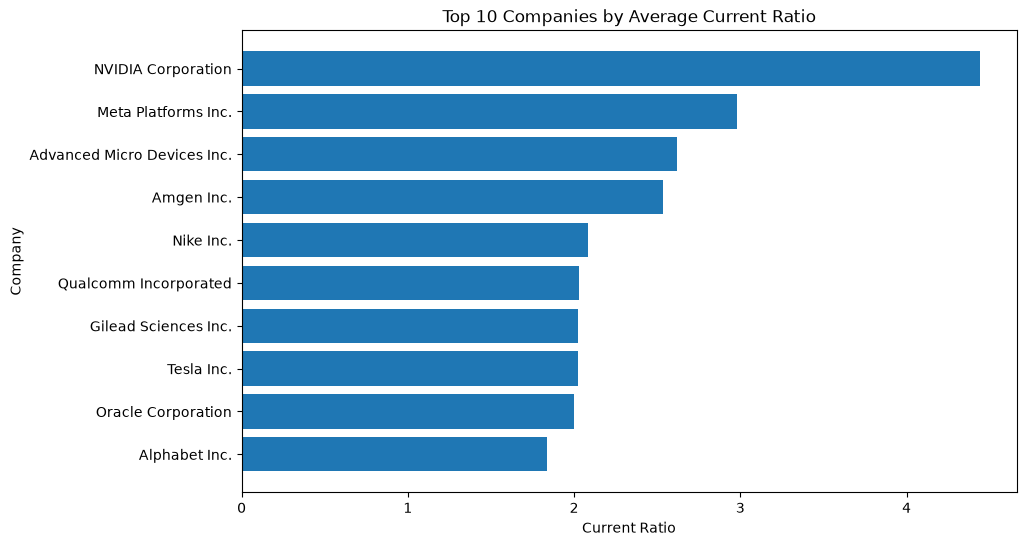

In [36]:
plt.figure(figsize=(10, 6))

plt.barh(
    liquidity_chart_df["company_name"],
    liquidity_chart_df["current_ratio"]
)

plt.xlabel("Current Ratio")
plt.ylabel("Company")
plt.title("Top 10 Companies by Average Current Ratio")

plt.gca().invert_yaxis()

plt.show()

**Leverage Analysis**

<span style="font-size:12pt">
Leverage analysis was conducted using the debt-to-equity ratio, calculated as long-term debt divided by shareholders' equity. While equity information was available for 425 observations, only 80 observations contained both long-term debt and equity values required for the calculation. Therefore, leverage comparisons are based on a reduced sample and should be interpreted with caution.
</span>


In [37]:
leverage_df = df[
    [
        "company_name",
        "ticker",
        "period_end",
        "long_term_debt",
        "equity"
    ]
]

leverage_df.head()

,company_name,ticker,period_end,long_term_debt,equity
0,Microsoft Corporation,MSFT,2008-06-30,NaN,NaN
1,Microsoft Corporation,MSFT,2009-06-30,NaN,NaN
2,Microsoft Corporation,MSFT,2010-06-30,NaN,4.617500e+10
3,Microsoft Corporation,MSFT,2012-06-30,NaN,6.636300e+10
4,Microsoft Corporation,MSFT,2014-06-30,NaN,NaN


In [38]:
leverage_df.notna().sum()

company_name      880
ticker            880
period_end        880
long_term_debt    128
equity            425
dtype: int64

##### Debt to Equity Ratio Summary

In [39]:
leverage_df["debt_to_equity"] = (
    leverage_df["long_term_debt"]
    /
    leverage_df["equity"]
)

leverage_df["debt_to_equity"].describe()

count    80.000000
mean      1.136474
std       1.157162
min      -2.558990
25%       0.525234
50%       1.008645
75%       1.840398
max       5.300510
Name: debt_to_equity, dtype: float64

In [40]:
leverage_df[
    leverage_df["debt_to_equity"] < 0
][
    [
        "company_name",
        "ticker",
        "long_term_debt",
        "equity",
        "debt_to_equity"
    ]
]

,company_name,ticker,long_term_debt,equity,debt_to_equity
702,Starbucks Corporation,SBUX,1.361690e+10,-5.321200e+09,-2.558990
703,Starbucks Corporation,SBUX,1.311990e+10,-8.706600e+09,-1.506891
704,Starbucks Corporation,SBUX,1.354760e+10,-7.994800e+09,-1.694551
705,Starbucks Corporation,SBUX,1.431950e+10,-7.448900e+09,-1.922364


In [41]:
##Positive Leverage 
positive_equity_leverage_df = leverage_df[
    leverage_df["equity"] > 0
]

In [42]:
## Company-level Leverage

company_leverage_df = (
    positive_equity_leverage_df[
        [
            "company_name",
            "ticker",
            "debt_to_equity"
        ]
    ]
    .groupby(
        ["company_name", "ticker"],
        as_index=False
    )
    .mean()
)

In [43]:
##top company leverage
 
top_leverage = (
    company_leverage_df
    .sort_values(
        by="debt_to_equity",
        ascending=False
    )
)

top_leverage.head(10)

,company_name,ticker,debt_to_equity
35,PepsiCo Inc.,PEP,2.423135
17,Eli Lilly and Company,LLY,2.281253
24,International Business Machines Corporation,IBM,2.133104
26,Mastercard Incorporated,MA,1.878634
0,3M Company,MMM,1.545428
20,Gilead Sciences Inc.,GILD,1.223689
11,Bristol Mayers Squibb Company,BMY,1.188166
28,Merck & Co. Inc.,MRK,0.768624
36,Pfizer Inc.,PFE,0.536446
33,Nike Inc.,NKE,0.501122


**Company-Level Leverage Comparison**

<span style="font-size:12pt">

Companies were ranked based on their average debt-to-equity ratio using observations with positive shareholders' equity.  PepsiCo recorded the highest average leverage ratio at **2.42**, followed by Eli Lilly (**2.28**) and IBM (**2.13**). The results show that several large established companies use debt financing as part of their capital structure. Healthcare companies were particularly represented among higher-leverage firms, reflecting the industry's reliance on long-term investment and financing. However, leverage should be evaluated alongside profitability and cash flow metrics because debt usage can support growth when managed effectively.
</span>

In [44]:
## Company-level leverage chart

leverage_chart_df = top_leverage.head(10)

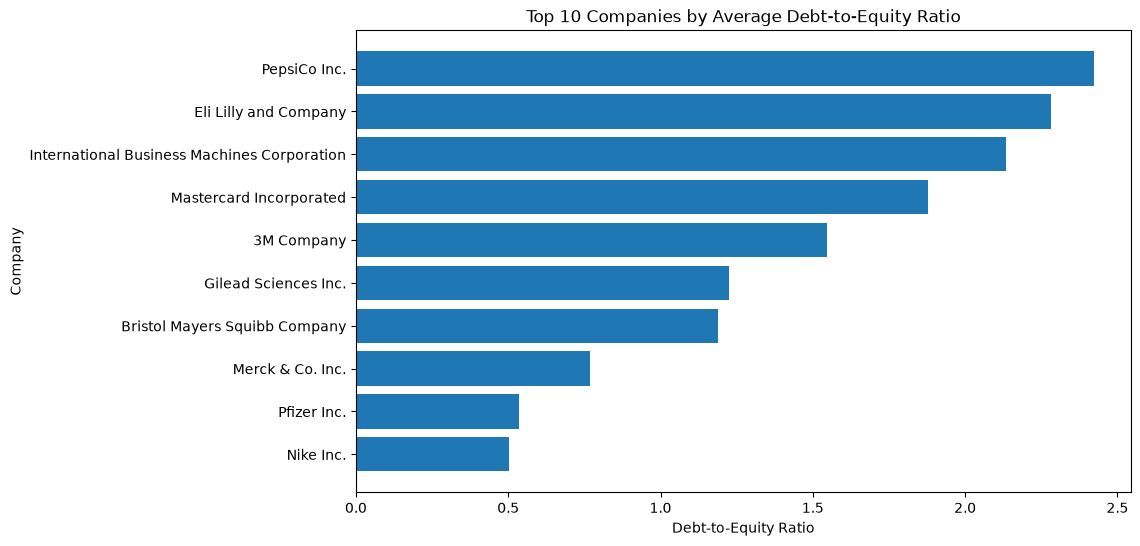

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    leverage_chart_df["company_name"],
    leverage_chart_df["debt_to_equity"]
)

plt.xlabel("Debt-to-Equity Ratio")
plt.ylabel("Company")
plt.title("Top 10 Companies by Average Debt-to-Equity Ratio")

plt.gca().invert_yaxis()

plt.show()

**Cash Flow Analysis**

Cash flow variables had relatively strong coverage compared with other financial metrics. Operating cash flow was available for 778 observations, while investing and financing cash flows were available for approximately 89% of the dataset. Due to the higher data availability, cash flow comparisons provide a more reliable view of companies' ability to generate and manage cash.

In [46]:
cashflow_df = df[
    [
        "company_name",
        "ticker",
        "period_end",
        "operating_cash_flow",
        "investing_cash_flow",
        "financing_cash_flow"
    ]
]

cashflow_df.head()

,company_name,ticker,period_end,operating_cash_flow,investing_cash_flow,financing_cash_flow
0,Microsoft Corporation,MSFT,2008-06-30,2.161200e+10,-4.587000e+09,-1.293400e+10
1,Microsoft Corporation,MSFT,2009-06-30,1.903700e+10,-1.577000e+10,-7.463000e+09
2,Microsoft Corporation,MSFT,2010-06-30,2.407300e+10,-1.131400e+10,-1.329100e+10
3,Microsoft Corporation,MSFT,2012-06-30,NaN,NaN,NaN
4,Microsoft Corporation,MSFT,2014-06-30,NaN,NaN,NaN


In [47]:
cashflow_df.notna().sum()

company_name           880
ticker                 880
period_end             880
operating_cash_flow    778
investing_cash_flow    780
financing_cash_flow    781
dtype: int64

In [48]:
company_cashflow_df = (
    cashflow_df[
        [
            "company_name",
            "ticker",
            "operating_cash_flow"
        ]
    ]
    .dropna()
    .groupby(
        ["company_name", "ticker"],
        as_index=False
    )
    .mean()
)

In [49]:
top_cashflow = (
    company_cashflow_df
    .sort_values(
        by="operating_cash_flow",
        ascending=False
    )
)

top_cashflow.head(10)

,company_name,ticker,operating_cash_flow
8,Apple Inc.,AAPL,7.592664e+10
4,Alphabet Inc.,GOOGL,7.210358e+10
33,Microsoft Corporation,MSFT,5.944417e+10
20,Exxon Mobil Corporation,XOM,4.135929e+10
32,Meta Platforms Inc.,META,3.479906e+10
5,Amazon.com Inc.,AMZN,3.403232e+10
13,Chevron Corporation,CVX,2.930917e+10
48,Walmart Inc.,WMT,2.835516e+10
9,Bank of America Corporation,BAC,2.598286e+10
28,Johnson & Johnson,JNJ,1.965811e+10


**Operating Cash Flow Comparison**

Companies were ranked based on their average operating cash flow across available reporting periods.

Apple recorded the highest average operating cash flow at approximately **$75.9 billion**, followed by Alphabet (**$72.1 billion**) and Microsoft (**$59.4 billion**). Technology companies dominated the ranking, reflecting their ability to generate substantial cash from large-scale operations and recurring revenue models.

Energy companies such as Exxon Mobil and Chevron also ranked highly, demonstrating the significant cash-generating capacity of commodity-based businesses. These results highlight the difference between profitability and cash generation, as companies with the highest margins are not always the largest cash producers.

In [50]:
cashflow_chart_df = top_cashflow.head(10)

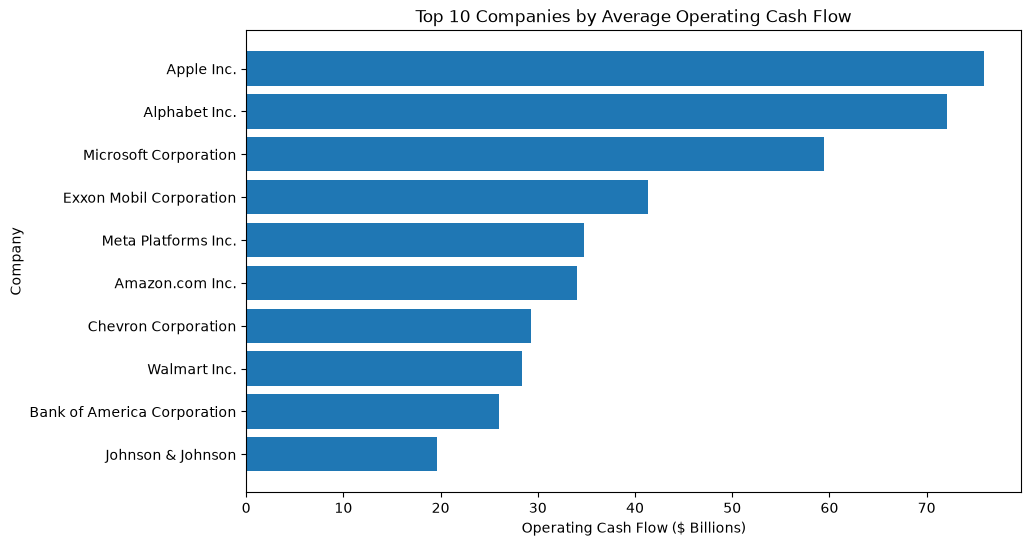

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    cashflow_chart_df["company_name"],
    cashflow_chart_df["operating_cash_flow"] / 1e9
)

plt.xlabel("Operating Cash Flow ($ Billions)")
plt.ylabel("Company")
plt.title("Top 10 Companies by Average Operating Cash Flow")

plt.gca().invert_yaxis()

plt.show()

**Trend Analysis**

Revenue trend analysis was conducted using 250 available company-period observations. Although the overall dataset contains 880 observations, revenue information was only available for a subset of companies and reporting periods. Therefore, revenue trends represent companies with sufficient historical revenue data rather than the complete sample.

In [52]:
revenue_trend_df = df[
    [
        "company_name",
        "ticker",
        "period_end",
        "revenue"
    ]
].dropna()

revenue_trend_df.head()

,company_name,ticker,period_end,revenue
6,Microsoft Corporation,MSFT,2016-06-30,9.115400e+10
7,Microsoft Corporation,MSFT,2017-06-30,9.657100e+10
8,Microsoft Corporation,MSFT,2018-06-30,1.103600e+11
9,Microsoft Corporation,MSFT,2019-06-30,1.258430e+11
10,Microsoft Corporation,MSFT,2020-06-30,1.430150e+11


In [53]:
revenue_trend_df.shape

(250, 4)

In [54]:
selected_companies = [
    "Apple Inc.",
    "Microsoft Corporation",
    "Alphabet Inc.",
    "Amazon.com Inc.",
    "Meta Platforms Inc."
]

In [55]:
revenue_selected_df = revenue_trend_df[
    revenue_trend_df["company_name"].isin(selected_companies)
]

In [56]:
revenue_selected_df.head()

,company_name,ticker,period_end,revenue
6,Microsoft Corporation,MSFT,2016-06-30,9.115400e+10
7,Microsoft Corporation,MSFT,2017-06-30,9.657100e+10
8,Microsoft Corporation,MSFT,2018-06-30,1.103600e+11
9,Microsoft Corporation,MSFT,2019-06-30,1.258430e+11
10,Microsoft Corporation,MSFT,2020-06-30,1.430150e+11


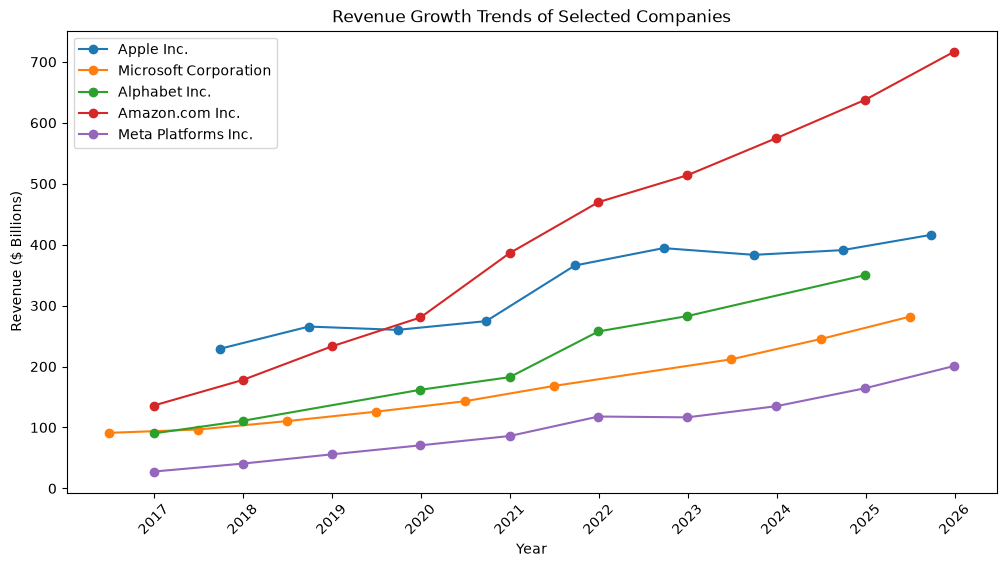

In [57]:
plt.figure(figsize=(12, 6))

for company in selected_companies:
    company_data = revenue_selected_df[
        revenue_selected_df["company_name"] == company
    ]
    
    plt.plot(
        company_data["period_end"],
        company_data["revenue"] / 1e9,
        marker="o",
        label=company
    )

plt.xlabel("Year")
plt.ylabel("Revenue ($ Billions)")
plt.title("Revenue Growth Trends of Selected Companies")

plt.legend()
plt.xticks(rotation=45)

plt.show()

**Net Income Trends**

Net income trend analysis was conducted using 749 available company-period observations. Compared with revenue data, net income had substantially higher coverage, allowing for a more complete assessment of profitability trends across companies and reporting periods.

In [58]:
net_income_trend_df = df[
    [
        "company_name",
        "ticker",
        "period_end",
        "net_income"
    ]
].dropna()

net_income_trend_df.shape

(749, 4)

In [59]:
selected_companies = [
    "Apple Inc.",
    "Microsoft Corporation",
    "Alphabet Inc.",
    "Amazon.com Inc.",
    "Meta Platforms Inc."
]

In [60]:
net_income_selected_df = net_income_trend_df[
    net_income_trend_df["company_name"].isin(selected_companies)
]

In [61]:
net_income_trend_df.shape

(749, 4)

In [62]:
selected_companies = [
    "Apple Inc.",
    "Microsoft Corporation",
    "Alphabet Inc.",
    "Amazon.com Inc.",
    "Meta Platforms Inc."
]

net_income_selected_df = net_income_trend_df[
    net_income_trend_df["company_name"].isin(selected_companies)
]

In [63]:
net_income_selected_df.head()

,company_name,ticker,period_end,net_income
0,Microsoft Corporation,MSFT,2008-06-30,1.768100e+10
1,Microsoft Corporation,MSFT,2009-06-30,1.456900e+10
2,Microsoft Corporation,MSFT,2010-06-30,1.876000e+10
3,Microsoft Corporation,MSFT,2012-06-30,1.697800e+10
4,Microsoft Corporation,MSFT,2014-06-30,2.207400e+10


In [64]:
net_income_selected_df = (
    net_income_selected_df
    .sort_values(
        by=["company_name", "period_end"]
    )
)

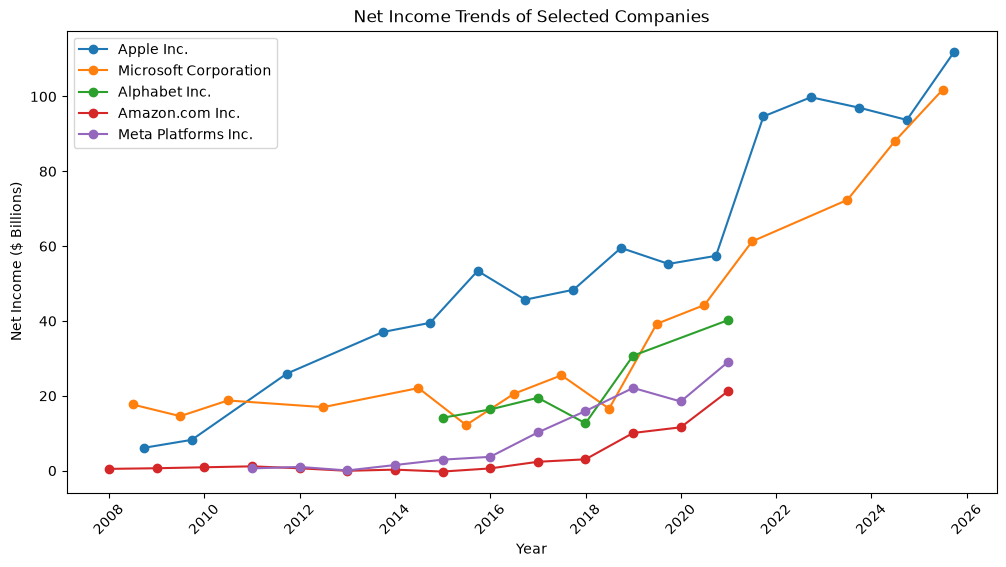

In [65]:
plt.figure(figsize=(12, 6))

for company in selected_companies:
    company_data = net_income_selected_df[
        net_income_selected_df["company_name"] == company
    ]
    
    plt.plot(
        company_data["period_end"],
        company_data["net_income"] / 1e9,
        marker="o",
        label=company
    )

plt.xlabel("Year")
plt.ylabel("Net Income ($ Billions)")
plt.title("Net Income Trends of Selected Companies")

plt.legend()
plt.xticks(rotation=45)

plt.show()


**Operating Margin Trend**

In [66]:
operating_margin_trend_df = profitability_df[
    [
        "company_name",
        "ticker",
        "period_end",
        "operating_margin"
    ]
].dropna()

operating_margin_trend_df.head()

,company_name,ticker,period_end,operating_margin
6,Microsoft Corporation,MSFT,2016-06-30,0.286087
7,Microsoft Corporation,MSFT,2017-06-30,0.300556
8,Microsoft Corporation,MSFT,2018-06-30,0.317669
9,Microsoft Corporation,MSFT,2019-06-30,0.341370
10,Microsoft Corporation,MSFT,2020-06-30,0.370304


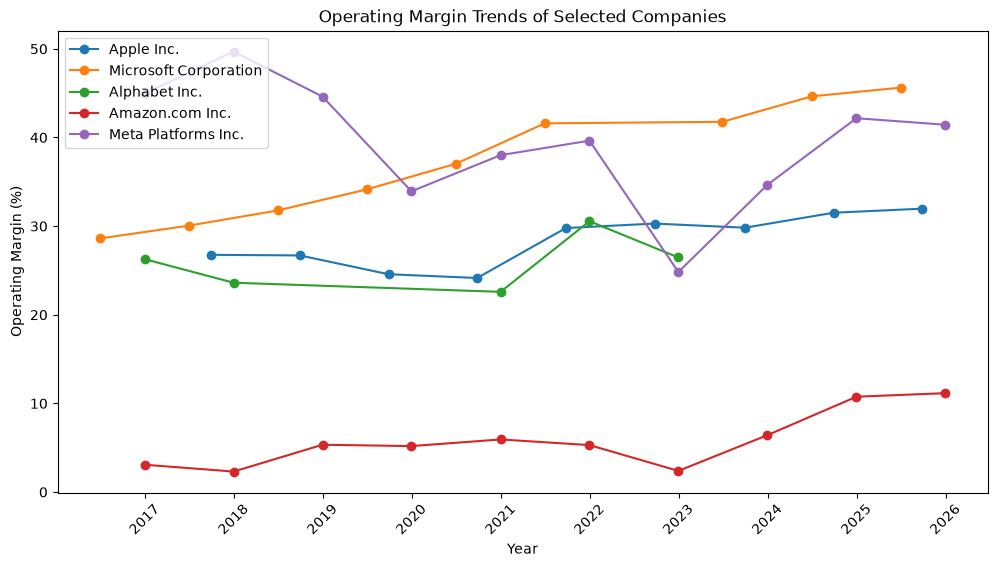

In [67]:
plt.figure(figsize=(12, 6))

for company in selected_companies:
    company_data = operating_margin_trend_df[
        operating_margin_trend_df["company_name"] == company
    ]
    
    plt.plot(
        company_data["period_end"],
        company_data["operating_margin"] * 100,
        marker="o",
        label=company
    )

plt.xlabel("Year")
plt.ylabel("Operating Margin (%)")
plt.title("Operating Margin Trends of Selected Companies")

plt.legend()
plt.xticks(rotation=45)

plt.show()

**Power BI Tables**

In [68]:
power_bi_analysis_df = df.copy()

In [69]:
power_bi_analysis_df.columns

Index(['company_id', 'period_start', 'period_end', 'fiscal_year',
       'fiscal_period', 'filing_form', 'filed_date', 'revenue',
       'operating_income', 'net_income', 'rd_expense', 'income_tax', 'assets',
       'liabilities', 'equity', 'cash', 'inventory', 'current_assets',
       'current_liabilities', 'long_term_debt', 'operating_cash_flow',
       'investing_cash_flow', 'financing_cash_flow', 'capital_expenditure',
       'dividends_paid', 'ticker', 'company_name', 'sector', 'country',
       'industry', 'exchange'],
      dtype='str')

In [70]:
power_bi_analysis_df["operating_margin"] = (
    power_bi_analysis_df["operating_income"] /
    power_bi_analysis_df["revenue"]
)

power_bi_analysis_df["net_profit_margin"] = (
    power_bi_analysis_df["net_income"] /
    power_bi_analysis_df["revenue"]
)

In [71]:
power_bi_company_summary_df = (
    power_bi_analysis_df
    .groupby(
        [
            "company_name",
            "ticker",
            "sector"
        ],
        as_index=False
    )
    .agg(
        {
            "revenue": "mean",
            "net_income": "mean",
            "operating_margin": "mean",
            "net_profit_margin": "mean",
            "operating_cash_flow": "mean"
        }
    )
)

In [72]:
power_bi_company_summary_df.isna().sum()

company_name            0
ticker                  0
sector                  0
revenue                18
net_income              0
operating_margin       26
net_profit_margin      19
operating_cash_flow     0
dtype: int64

In [73]:
## Revenue Trend - PowerBI

power_bi_revenue_df = power_bi_analysis_df[
    [
        "company_name",
        "ticker",
        "sector",
        "period_end",
        "revenue"
    ]
].dropna()

In [74]:
## Profitability Trend - PowerBI

power_bi_profitability_df = power_bi_analysis_df[
    [
        "company_name",
        "ticker",
        "sector",
        "period_end",
        "net_income",
        "operating_margin",
        "net_profit_margin"
    ]
].dropna()

In [75]:
## Cash flow Trend

power_bi_cashflow_df = power_bi_analysis_df[
    [
        "company_name",
        "ticker",
        "sector",
        "period_end",
        "operating_cash_flow"
    ]
].dropna()

**Export Tables**

In [76]:
power_bi_company_summary_df.to_csv(
    "power_bi_company_overview.csv",
    index=False
)

In [77]:
power_bi_revenue_df.to_csv(
 "power_bi_revenue_trend.csv",
 index=False
)

In [78]:
power_bi_profitability_df.to_csv(
    "power_bi_profitability_trend.csv",
    index=False
)

In [79]:
power_bi_cashflow_df.to_csv(
    "power_bi_cashflow_trend.csv",
    index=False
)

In [80]:
power_bi_company_summary_df["ticker"].is_unique

True

In [81]:
company_liquidity_df.to_csv("power_bi_company_liquidity.csv", index=False)

In [82]:
company_leverage_df.to_csv("power_bi_company_leverage.csv", index=False)

In [83]:
liquidity_chart_df.to_csv("power_bi_liquidity_chart.csv", index=False)